# Exercises Week 8

## Exercise 1: AdaBoost and VC-dimension
In this exericse, we will investigate the VC-dimension of voting classifiers and argue that one has to be careful with the number of iterations of boosting to guarantee good generalization performance with high probability.

The data we will consider is one-dimensional, i.e. a single feature. Our weak learner is decision stumps, i.e. a base hypothesis $h$ can be specified by a splitting value $v$, and two leaf values $a, b \in \{-1,1\}$. Given a one-dimensional feature vector $x = (x_1)$, the hypothesis $h$ returns $a$ when $x_1 \leq v$ and it returns $b$ otherwise. We let $H$ denote the set of all such decision stumps, i.e. $H$ is the set of base hypotheses.

### VC-dimension of base classifier
1. Show that the VC-dimension of $H$ is $2$.

- If we have 2 points with 4 possible labelings, and we choose $x_1=1$ and $x_2=2$ then $v=1.5$ splits these values therefore $d \geq 2$
- With one split, we can not shatter $x_1=+1$, $x_2=-1$ and $x_3=+1$, since this would require 2 splits so $d<3$

### VC-dimension of voting classifiers
Let $C$ be the class of all voting classifiers over $H$, i.e. $C$ consists of all hypotheses of the form:
$$
f(x) = \textrm{sign}(\sum_{h \in H} \alpha_h h(x))
$$
We will show that $C$ has infinite VC-dimension. To do so, we will argue that for any size $n$, there is a set of $n$ points $x_1,\dots,x_n$ in 1d that can be shattered, i.e. for any labeling $y \in \{-1,1\}^n$ of the $n$ points, there is a hypothesis $g$ in $C$ such that $g(x_i)=y_i$ for all $i$. 

2. First argue that for any interval $[a, b]$ and value $z \in \{-1,1\}$, it is possible to find decision stumps $h_1,h_2$ such that for $x \in (a, b]$, we have $h_1(x)+h_2(x) = 2z$ and for any $x \notin (a, b]$, we have $h_1(x) + h_2(x) = 0$.
- $h_1(x) = -z$ if $x \leq v_1$ and $h_1(x) = z$ if $x > v_1$. 
- $h_2(x) = z$ if $x \leq v_2$ and $h_2(x) = -z$ if $x > v_2$.
- Then $h_1(x)+h_2(x)$ fit the criteria   

3. Use what you showed in 2. to come up with a 1d data set of size $n$ that you can shatter, i.e. generate any possible dichotomy/labeling using a voting classifier from $C$.
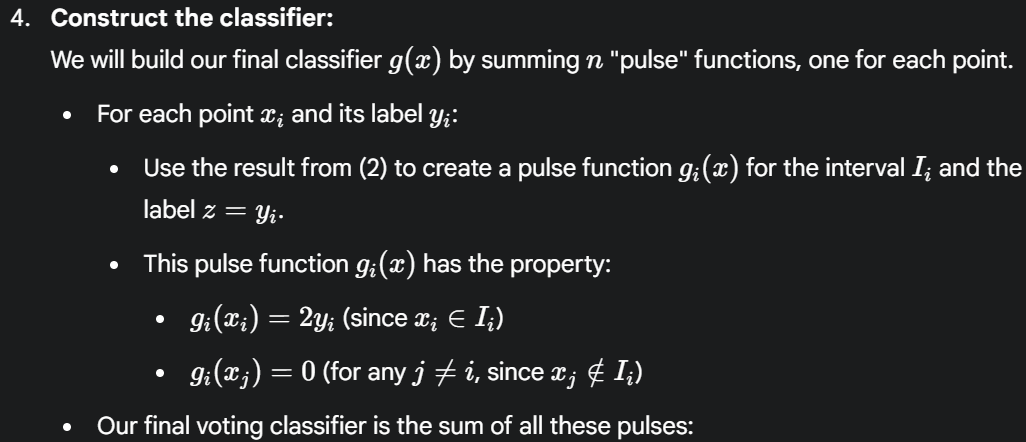
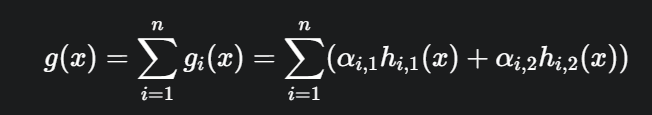

### Growth function for few base learners
Finally, consider if we restrict ourselves to only using voting classifiers that combine the predictions of no more than $T$ base hypotheses. To simplify the exercise, we will even assume that we use precisely the coefficients $\alpha_h=1$ for the $T$ hypotheses. That is, we consider the set of voting classifiers $C^T$ containing all hypotheses of the form:
$$
f(x) = \textrm{sign}(\sum_{i=1}^T h_i(x))
$$
where $h_1,\dots,h_T$ are hypotheses from $H$.

Recall that we have generalization bounds in terms of the growth function $m_H(n)$:
$$
\Pr[|E_{out}(h^*)-E_{in}(h^*)| > \varepsilon] < 8m_H(2n)e^{-\varepsilon^2 n/8}.
$$

4. What is the growth function $m_H(n)$ when $H$ is the set of decision stumps on 1d data?
- If a and b are the same, then we have 1 dichometry so 2 $\pm 1$
- If a and b are not the same (ie. $a =1$ and $b=-1$) we have $(n-1)$ 
- So $m_H(n) = 2 + (n-1) + (n-1) = 2n$ 

5. What is a good upper bound on the growth function $m_{C^T}(n)$?
- ?

## Exercise 2: Implementing AdaBoost
In this exercise your task is to implement AdaBoost as described in the lecture and the Boosting note.
We have provided starter code in adaboost.py. See the boosting note for a description of the algorithm.

You must implement the methods
- ensemble_output
- exp_loss
- predict
- score
- fit

in that order

To test your implementation, run adaboost.py

You should get a final accuracy of around 0.886



## Exercise 3: Gradient Boosting by Hand
In this exercise you must complete one step of gradient boosting with exponential loss on a small 1d data set (X, y) as shown below. The exponential loss is $L(h(x),y) = e^{-yh(x)}$.

$X = [1,2,5,3,4]^\intercal$

$y = [1,1,1,-1, -1]^\intercal$

Assume that we initialize our ensemble model with the constant function $h(x) = 1$


**Your task requires the following three steps** 
1. Compute the "gradient" vector $\hat{y}$ (as in the slides) that we need to fit.
2. Construct the best Regression Stump for fitting $\hat{y}$.
3. Optimize the leaf values such that the newly added tree minimize the exponential loss, with the condition that the value the leaf returns is in the interval [-1, 1].
   What happens if we do not have this constraint that the leaf must return values in [-1, 1]?


## Exercise 4: Implementing Gradient Boosting
In this exercise your task is to implement the Gradient Boosting algorithm for regression using Least Squares Loss.
We have provided starter code in **gradientboost.py**. 

You must implement the methods
- predict
- score
- fit

in that order.

**Note**: To simplify the implementation, we will **not** require that the first hypothesis you train is a constant function. Instead, just train a regression tree and give it an $\alpha$ of $1$.

**Note**: For least squares loss, gradient boosting is MUCH simpler to implement. Concretely, in any iteration, once we have computed the best regression tree using least squares loss, gradient boosting would alter the leaf values to minimize the loss. However, for least squares loss, it is still the mean we would return. Hence we do not need to alter leaf return values at all!

Notice that fit gets two sets of data and labels X, y and X_val, y_val.
The latter X_val, y_val is a separate validation test set you must test your current ensemble on in each iteration so we can plot the development on data not used for training.

To test your implementation, run gradientboost.py -max_depth 1

You can provide different max_depth of the base learner which is a Regression Tree (1 is default).

With a default base learner with max depth 1 the mean least squares error on both training and test data should be around 0.54. 
If you change random state then the results may be different.

If you increase the max_depth the results will change.  Try for instance max_depth 3 and 5 as well. What do you see?



